In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("diabetic_data.csv")

In [ ]:
df = df.drop(columns=["encounter_id", "patient_nbr"], errors="ignore")

In [ ]:
df.isna().sum(axis=0).sort_values(ascending=False).head(5)

In [ ]:
df["max_glu_serum"] = df["max_glu_serum"].fillna("not_measured")
df["A1Cresult"] = df["A1Cresult"].fillna("not_measured")

In [ ]:
for col in df.columns:
    print(df[col].value_counts())
    print(df[col].dtype)
    print()

In [ ]:
df = df[df["gender"] != "Unknown/Invalid"]
df = df[~df["discharge_disposition_id"].isin([11, 13, 14, 19, 20, 21])] # смерть/хоспис
df = df.replace("?", np.nan)

In [ ]:
df["admission_type_id"] = df["admission_type_id"].astype(str)
df["discharge_disposition_id"] = df["discharge_disposition_id"].astype(str)
df["admission_source_id"] = df["admission_source_id"].astype(str)

In [ ]:
y = (df["readmitted"] == "<30").astype(int)
X = df.drop(columns=["readmitted", "weight", 'examide', 'citoglipton'], errors="ignore")

In [ ]:
X.head()

In [ ]:
y.mean()

In [ ]:
age_mapping = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

X["age_mid"] = X["age"].map(age_mapping)

In [ ]:
def map_icd9(code):

    if pd.isna(code):
        return 'Missing'

    code = str(code).strip()

    if code.startswith('V'):
        return 'Supplementary_Factors'

    if code.startswith('E'):
        return 'External_Causes'

    try:
        num = float(code)
    except ValueError:
        return 'Unknown'

    if 1 <= num <= 139:
        return 'Infectious_Parasitic'

    elif 140 <= num <= 239:
        return 'Neoplasms'

    elif 240 <= num <= 279:
        return 'Endocrine_Metabolic_Immunity'

    elif 280 <= num <= 289:
        return 'Blood_Diseases'

    elif 290 <= num <= 319:
        return 'Mental_Disorders'

    elif 320 <= num <= 389:
        return 'Nervous_Sense_Organs'

    elif 390 <= num <= 459:
        return 'Circulatory'

    elif 460 <= num <= 519:
        return 'Respiratory'

    elif 520 <= num <= 579:
        return 'Digestive'

    elif 580 <= num <= 629:
        return 'Genitourinary'

    elif 630 <= num <= 679:
        return 'Pregnancy_Childbirth'

    elif 680 <= num <= 709:
        return 'Skin_Subcutaneous'

    elif 710 <= num <= 739:
        return 'Musculoskeletal'

    elif 740 <= num <= 759:
        return 'Congenital_Anomalies'

    elif 760 <= num <= 779:
        return 'Perinatal'

    elif 780 <= num <= 799:
        return 'Symptoms_IllDefined'

    elif 800 <= num <= 999:
        return 'Injury_Poisoning'

    else:
        return 'Unknown'

for col in ["diag_1", "diag_2", "diag_3"]:
    X[col + "_group"] = X[col].apply(map_icd9)

In [ ]:
X["prior_visits"] = X["number_outpatient"] + X["number_emergency"] + X["number_inpatient"]

X["had_prior_inpatient"] = (X["number_inpatient"] > 0).astype(int)

X["treatment_intensity"] = X["num_lab_procedures"] + X["num_procedures"] + X["num_medications"]

X["many_medications"] = (X["num_medications"] >= X["num_medications"].quantile(0.75)).astype(int)

X["long_stay"] = (X["time_in_hospital"] >= X["time_in_hospital"].quantile(0.75)).astype(int)

In [ ]:
cat_features = X.select_dtypes(include=["str"]).columns.tolist()
num_features = X.select_dtypes(exclude=["str"]).columns.tolist()

In [ ]:
for col in cat_features:
    X[col] = X[col].fillna("missing")

for col in num_features:
    X[col] = X[col].fillna(X[col].median())

In [ ]:
from sklearn.model_selection import train_test_split

X_train_val, X_test_cal, y_train_val, y_test_cal = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=52
)

X_test, X_cal, y_test, y_cal = train_test_split(
    X_test_cal,
    y_test_cal,
    test_size=0.5,
    stratify=y_test_cal,
    random_state=52
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    stratify=y_train_val,
    random_state=52
)

In [ ]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(
    X_train,
    y_train,
    cat_features=cat_features
)

valid_pool = Pool(
    X_val,
    y_val,
    cat_features=cat_features
)

cal_pool = Pool(
    X_cal,
    y_cal,
    cat_features=cat_features
)

test_pool = Pool(
    X_test,
    y_test,
    cat_features=cat_features
)

In [ ]:
cb_model = CatBoostClassifier(
    iterations = 3000,
    learning_rate = 0.05,
    loss_function = "Logloss",
    eval_metric = "AUC",
    depth = 4,
    l2_leaf_reg = 5,
    auto_class_weights = "SqrtBalanced",
    random_seed = 52,
    early_stopping_rounds = 100,
    verbose = 100,
    allow_writing_files = False
)

cb_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

In [ ]:
best_iteration = cb_model.get_best_iteration()

final_cb_model = CatBoostClassifier(
    iterations=best_iteration + 1,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    depth = 4,
    l2_leaf_reg = 5,
    auto_class_weights = "SqrtBalanced",
    random_seed=52,
    verbose=100,
    allow_writing_files=False
)

final_train_pool = Pool(X_train_val, y_train_val, cat_features=cat_features)

final_cb_model.fit(final_train_pool)

In [ ]:
def evaluate_proba(y_true, proba):
    print("ROC AUC:", roc_auc_score(y_true, proba))
    print("PR AUC:", average_precision_score(y_true, proba))
    print("Mean predicted probability:", proba.mean())
    print("Real positive rate:", y_true.mean())
    print()


def evaluate_classification(y_true, y_pred_proba, threshold):
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    print("Threshold:", threshold)
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1:", f1_score(y_true, y_pred, zero_division=0))
    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()
    print("Classification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print()

In [ ]:
y_pred_test_proba = final_cb_model.predict_proba(test_pool)[:, 1]
y_pred_cal_proba = final_cb_model.predict_proba(cal_pool)[:, 1]

evaluate_proba(y_test, y_pred_test_proba)
evaluate_classification(y_test, y_pred_test_proba, threshold=0.113)

In [ ]:
eps = 1e-6

cat_logit_cal = np.log(np.clip(cal_proba, eps, 1 - eps) / (1 - np.clip(cal_proba, eps, 1 - eps))).reshape(-1, 1)
cat_logit_test = np.log(np.clip(test_proba, eps, 1 - eps) / (1 - np.clip(test_proba, eps, 1 - eps))).reshape(-1, 1)

In [ ]:
from sklearn.linear_model import LogisticRegression

calibrator = LogisticRegression()
calibrator.fit(cat_logit_cal, y_cal)
cat_proba_test_calibrated = calibrator.predict_proba(cat_logit_test)[:, 1]

In [ ]:
evaluate_proba(y_test, cat_proba_test_calibrated)

evaluate_classification(y_test, cat_proba_test_calibrated, threshold=0.113)

In [ ]:
test_results = X_test.copy()
test_results["target"] = y_test.values
test_results["predicted_risk"] = cat_proba_test_calibrated

In [ ]:
test_results.to_csv('model_hypo.csv', index=False)

In [2]:
test_results = pd.read_csv('model_hypo.csv')

Итак, теперь перейдем к гипотезам. Для начала проверим, что модель статистически значимо ранжирует пациентов по риску повторной госпитализации, т.е. мы проверяем, получают ли пациенты, которые фактически были повторно госпитализированы, более высокие значения predicted_risk

Н0 - Распределение predicted_risk одинаково у пациентов с target = 1 и target = 0 (эквивалентная интерпретация: ROC-AUC = 0.5)

Н1 - Распределение predicted_risk у пациентов с target = 1 сдвинуто вправо относительно пациентов с target = 0 (эквивалентная интерпретация: ROC-AUC > 0.5)

В качестве статистического теста используем односторонний тест [Манна-Уитни U](https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test). Это непараметрический тест для сравнения двух независимых выборок. Он подходит здесь, потому что мы сравниваем распределения риска у двух групп пациентов и не предполагаем нормальность predicted_risk

In [3]:
from scipy.stats import mannwhitneyu

risk_positive = test_results.loc[test_results["target"] == 1, "predicted_risk"]

risk_negative = test_results.loc[test_results["target"] == 0, "predicted_risk"]

mannwhitneyu(risk_positive, risk_negative, alternative="greater")

MannwhitneyuResult(statistic=np.float64(15201250.0), pvalue=np.float64(3.212300441414406e-127))

p-value оказалось значительно меньше 0.05, поэтому нулевая гипотеза отвергается - распределения отличаются и это означает что ROC-AUC > 0.5. Почему? ROC-AUC можно понимать очень просто: берем случайного пациента, который вернулся, и случайного пациента, который не вернулся. Смотрим, кому модель дала больший риск. Так делаем для всех возможных пар, и ROC-AUC будет доле таких пар где риск выше у пациента с target=1 среди всех возможных пар. Тест Манна-Уитни считает специальную величину U statistic, и оно как раз и связано с количеством таких пар. Мы можем в этом легко убедиться поделив его на общее количество пар

In [4]:
15201250.0 / (len(risk_negative) * len(risk_positive))

0.6784095353687397

Это как раз и равно нашему ROC-AUC. Также посмотрим визуально:

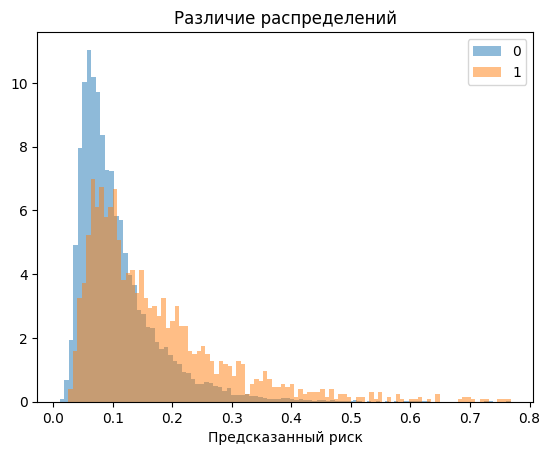

In [5]:
plt.hist(
    risk_negative,
    bins=100,
    alpha=0.5,
    density=True,
    label="0"
)

plt.hist(
    risk_positive,
    bins=100,
    alpha=0.5,
    density=True,
    label="1"
)

plt.xlabel("Предсказанный риск")
plt.title("Различие распределений")
plt.legend()
plt.show()

Отлично, мы убедились, что модель действительно извлекает полезный сигнал, изучим само распределение predicted_risk. Если распределение риска можно описать одним простым распределением, то пациенты скорее образуют одну относительно однородную массу. В таком случае можно использовать один общий порог риска. Если же распределение риска плохо описывается одним простым распределением и лучше аппроксимируется смесью нескольких компонент, это означает, что пациенты неоднородны. Тогда для бизнеса логичнее использовать сегментацию: low-risk, medium-risk, high-risk, и назначать разные уровни сопровождения.

Так как predicted_risk является вероятностью и лежит в интервале от 0 до 1, мы сначала применяем logit-преобразование:

In [6]:
eps = 1e-6
risk_clipped = np.clip(test_results["predicted_risk"].values, eps, 1 - eps)

test_results["logit_predicted_risk"] = np.log(risk_clipped / (1 - risk_clipped))

<Axes: >

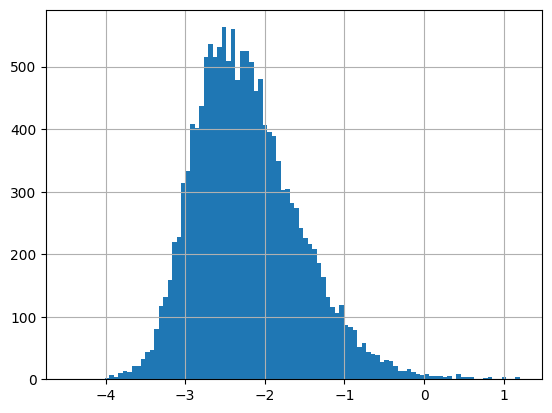

In [7]:
test_results["logit_predicted_risk"].hist(bins=100)

Проверим является ли распредение нормальным:

H0 - logit(predicted_risk) имеет нормальное распределение.

H1 - logit(predicted_risk) не имеет нормального распределения.

Поскольку мы нестандартно мыслим будем использовать [тест Д’Агостино - Пирсона](https://real-statistics.com/tests-normality-and-symmetry/statistical-tests-normality-symmetry/dagostino-pearson-test/). Он проверяет нормальность распределения через асимметрию и эксцесс. Если p-value меньше 0.05, мы отвергаем гипотезу нормальности.

In [8]:
from scipy import stats

stats.normaltest(test_results["logit_predicted_risk"])

NormaltestResult(statistic=np.float64(1187.366454597848), pvalue=np.float64(1.4677442428758787e-258))

p-value оказался намного меньше 0.05, поэтому мы отвергаем H0 о нормальности logit(predicted_risk). Дополнительно используем Q-Q plot для визуальной проверки отклонений от нормального распределения:

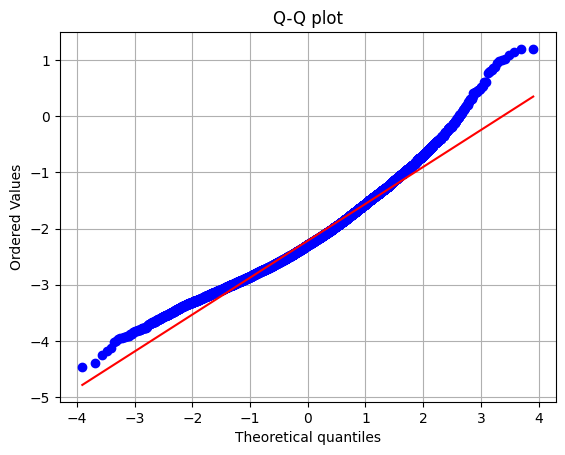

In [9]:
stats.probplot(
    test_results["logit_predicted_risk"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q plot")
plt.grid(True)
plt.show()

Q-Q plot также показывает заметные отклонения от прямой, особенно в хвостах распределения. Следовательно, несмотря на визуальную похожесть, распределение риска не описывается простой logit-normal моделью. Проверим, можно ли лучше описать распределение риска как смесь нескольких logit-normal распределений. В бизнес-интерпретации компоненты смеси можно рассматривать как естественные risk-сегменты пациентов.

Мы сравним Gaussian Mixture Models с разным числом компонент и выберем число компонент по BIC. BIC штрафует модель за излишнюю сложность. Поэтому если модель с несколькими компонентами имеет меньший BIC, это означает, что дополнительная сегментация улучшает описание распределения риска достаточно сильно, чтобы оправдать усложнение модели.

In [10]:
from sklearn.mixture import GaussianMixture

X_logit = test_results["logit_predicted_risk"].values.reshape(-1, 1)

gmm_results = []

for n_components in [1, 2, 3, 4, 5]:
    gmm = GaussianMixture(n_components=n_components, random_state=52)
    gmm.fit(X_logit)
    
    print("Компонент:", n_components)
    print("BIC", gmm.bic(X_logit))
    print()

Компонент: 1
BIC 30143.9802072106

Компонент: 2
BIC 29228.37617810467

Компонент: 3
BIC 29279.390580911073

Компонент: 4
BIC 29300.234382739436

Компонент: 5
BIC 29320.521348278427



BIC оказался минимальным при модели с двумя компонентами. Это означает, что распределение logit(predicted_risk) лучше описывается не одной нормальной компонентой, а смесью двух компонент. С бизнес-точки зрения это говорит о неоднородности пациентов по риску повторной госпитализации. Вместо того чтобы использовать один одинаковый процесс сопровождения для всех пациентов, можно выделить две группы: пациентов с базовым риском и пациентов с повышенным риском.